# Feed Cost Datasets: Exploratory Visualization
**Egg Price Shocks Project — External Covariate Analysis**

This notebook explores the two feed cost datasets we'll use as external covariates in the egg price shock attribution analysis (Aim 4). Prices are expressed as **log prices** throughout; differences of log prices equal continuously compounded (log) returns.

### Datasets
| Dataset | Variable | Source | Coverage | Units |
|---|---|---|---|---|
| `WPU02930102.csv` | BLS Producer Price Index — Prepared feeds for animals | BLS via FRED | Dec 1986 – Feb 2026 | Log index (base = 100, Dec 1986) |
| `corn_price_fred.csv` | World corn price | IMF via FRED (`PMAIZMTUSDM`) | Jan 1992 – present | Log USD per metric ton |

### Why log prices?
Log-transforming commodity prices before analysis has several practical advantages:
1. **Symmetry**: a 50% rise and a 50% fall have equal magnitude in log space (±0.405), unlike raw percent changes (+50% vs −33%)
2. **Variance stabilisation**: commodity price volatility tends to scale with price level; log-prices remove most of this heteroskedasticity
3. **Additivity**: log-returns (first differences of log prices) are directly interpretable as continuously compounded growth rates and sum correctly over time
4. **Model compatibility**: most time-series models (VAR, VECM, state-space) assume covariance stationarity of the differenced series — log-returns are better behaved than raw percent changes for large shocks like 2008 and 2022

### Why these matter
Feed costs are one of the largest input costs for egg production. Muhammad et al. (2023) found that feed costs contributed roughly as much to the 2022 egg price spike as bird losses from HPAI — so this is not just a background variable. The goal here is to:
1. Understand each series individually (trend, volatility, major episodes)
2. Compare them to each other — do they move together?
3. Look ahead: do feed spikes *lead* egg price shocks, and by how long?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11
})

print('Libraries loaded.')

Libraries loaded.


## 1. Load, Inspect, and Log-Transform the Data

Upload the two CSV files (`WPU02930102.csv` and `corn_price_fred.csv`) to this Colab session,
then run the cell below. If you're running locally, just place the files in the same directory.

Log prices are computed immediately after loading. All downstream analysis uses the `_log` columns.

In [ ]:
# --- Load feed PPI (BLS WPU02930102) ---
feed_ppi = pd.read_csv('WPU02930102.csv', parse_dates=['observation_date'])
feed_ppi = feed_ppi.rename(columns={'observation_date': 'date', 'WPU02930102': 'feed_ppi'})
feed_ppi = feed_ppi.set_index('date').sort_index()
feed_ppi['feed_ppi_log'] = np.log(feed_ppi['feed_ppi'])

# --- Load corn price (IMF/FRED PMAIZMTUSDM) ---
corn = pd.read_csv('corn_price_fred.csv', parse_dates=['observation_date'])
corn = corn.rename(columns={'observation_date': 'date', 'PMAIZMTUSDM': 'corn_usd_per_mt'})
corn = corn.set_index('date').sort_index()
corn['corn_log'] = np.log(corn['corn_usd_per_mt'])

print('Feed PPI:')
print(f'  Range: {feed_ppi.index.min().date()} to {feed_ppi.index.max().date()}')
print(f'  Observations: {len(feed_ppi)}')
print(f'  Log price — Min: {feed_ppi.feed_ppi_log.min():.3f} | Max: {feed_ppi.feed_ppi_log.max():.3f}  '
      f'(raw: {feed_ppi.feed_ppi.min():.1f} – {feed_ppi.feed_ppi.max():.1f})\n')

print('Corn Price:')
print(f'  Range: {corn.index.min().date()} to {corn.index.max().date()}')
print(f'  Observations: {len(corn)}')
print(f'  Log price — Min: {corn.corn_log.min():.3f} | Max: {corn.corn_log.max():.3f}  '
      f'(raw: ${corn.corn_usd_per_mt.min():.2f} – ${corn.corn_usd_per_mt.max():.2f} per MT)')

Feed PPI:
  Range: 1986-12-01 to 2026-02-01
  Observations: 471
  Log price — Min: 4.572 | Max: 5.732  (raw: 96.7 – 308.6)

Corn Price:
  Range: 1992-01-01 to 2026-02-01
  Observations: 410
  Log price — Min: 4.318 | Max: 5.854  (raw: $75.06 – $348.51 per MT)


---
## 2. Dataset 1 — BLS Feed Producer Price Index (`WPU02930102`)

This is the PPI for *prepared feeds for animals*, which directly tracks what egg producers pay for compound feed. The index is rebased to 100 at December 1986. We work with log prices throughout: **Panel 1** shows the log-price level, **Panel 2** shows month-over-month log-returns (first differences of log prices), and **Panel 3** shows rolling 12-month volatility of those log-returns.

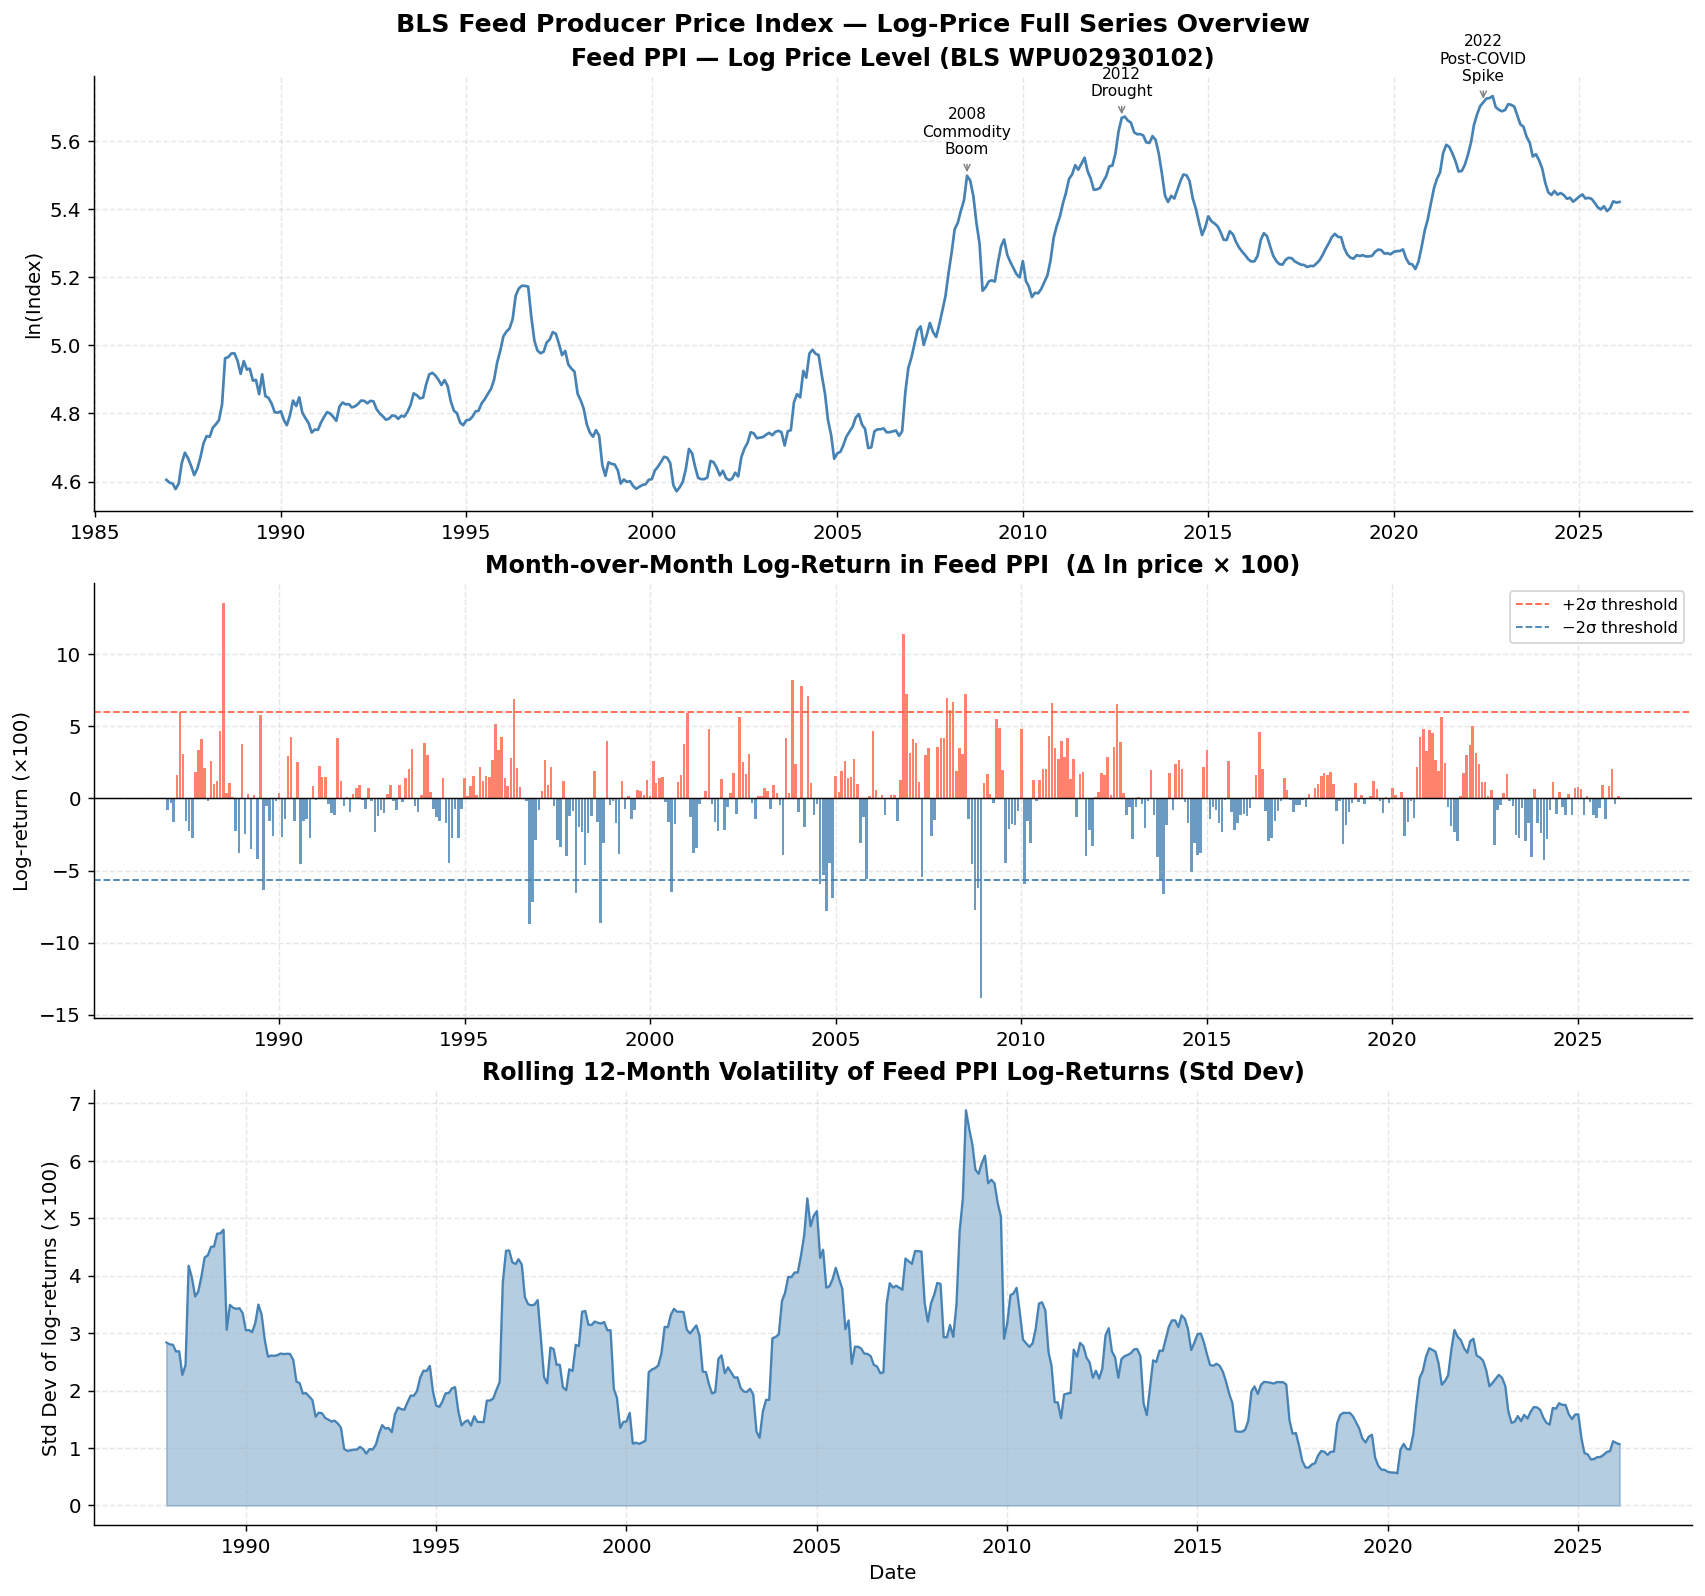

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), constrained_layout=True)

# ── Panel 1: Log price level ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(feed_ppi.index, feed_ppi.feed_ppi_log, color='steelblue', lw=1.5)
ax.set_title('Feed PPI — Log Price Level (BLS WPU02930102)', fontweight='bold')
ax.set_ylabel('ln(Index)')

# Annotate notable peaks
notable = {
    '2008-07-01': ('2008\nCommodity\nBoom', 'top'),
    '2012-09-01': ('2012\nDrought', 'top'),
    '2022-06-01': ('2022\nPost-COVID\nSpike', 'top'),
}
for date_str, (label, va) in notable.items():
    dt = pd.Timestamp(date_str)
    if dt in feed_ppi.index:
        val = feed_ppi.loc[dt, 'feed_ppi_log']
        ax.annotate(label, xy=(dt, val), xytext=(0, 12),
                    textcoords='offset points', ha='center', fontsize=8.5,
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# ── Panel 2: Month-over-month log-returns ─────────────────────────────────────
ax2 = axes[1]
log_ret = feed_ppi.feed_ppi_log.diff() * 100  # in percentage points for readability
colors = ['tomato' if x > 0 else 'steelblue' for x in log_ret]
ax2.bar(feed_ppi.index, log_ret, color=colors, width=25, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(log_ret.mean() + 2*log_ret.std(), color='tomato',
            lw=1, ls='--', label='+2σ threshold')
ax2.axhline(log_ret.mean() - 2*log_ret.std(), color='steelblue',
            lw=1, ls='--', label='−2σ threshold')
ax2.set_title('Month-over-Month Log-Return in Feed PPI  (Δ ln price × 100)', fontweight='bold')
ax2.set_ylabel('Log-return (×100)')
ax2.legend(fontsize=9)

# ── Panel 3: Rolling 12-month standard deviation of log-returns ───────────────
ax3 = axes[2]
roll_std = feed_ppi.feed_ppi_log.diff().rolling(12).std() * 100
ax3.fill_between(feed_ppi.index, roll_std, alpha=0.4, color='steelblue')
ax3.plot(feed_ppi.index, roll_std, color='steelblue', lw=1.2)
ax3.set_title('Rolling 12-Month Volatility of Feed PPI Log-Returns (Std Dev)', fontweight='bold')
ax3.set_ylabel('Std Dev of log-returns (×100)')
ax3.set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('BLS Feed Producer Price Index — Log-Price Full Series Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

---
## 3. Dataset 2 — World Corn Price (log USD/MT)

Corn is the primary ingredient in poultry feed (typically 50–60% of the ration by weight), making world corn prices a key upstream driver of feed costs and, eventually, egg prices. This series comes from the IMF Primary Commodity Price database via FRED. All three panels mirror the structure of Section 2, using log prices.

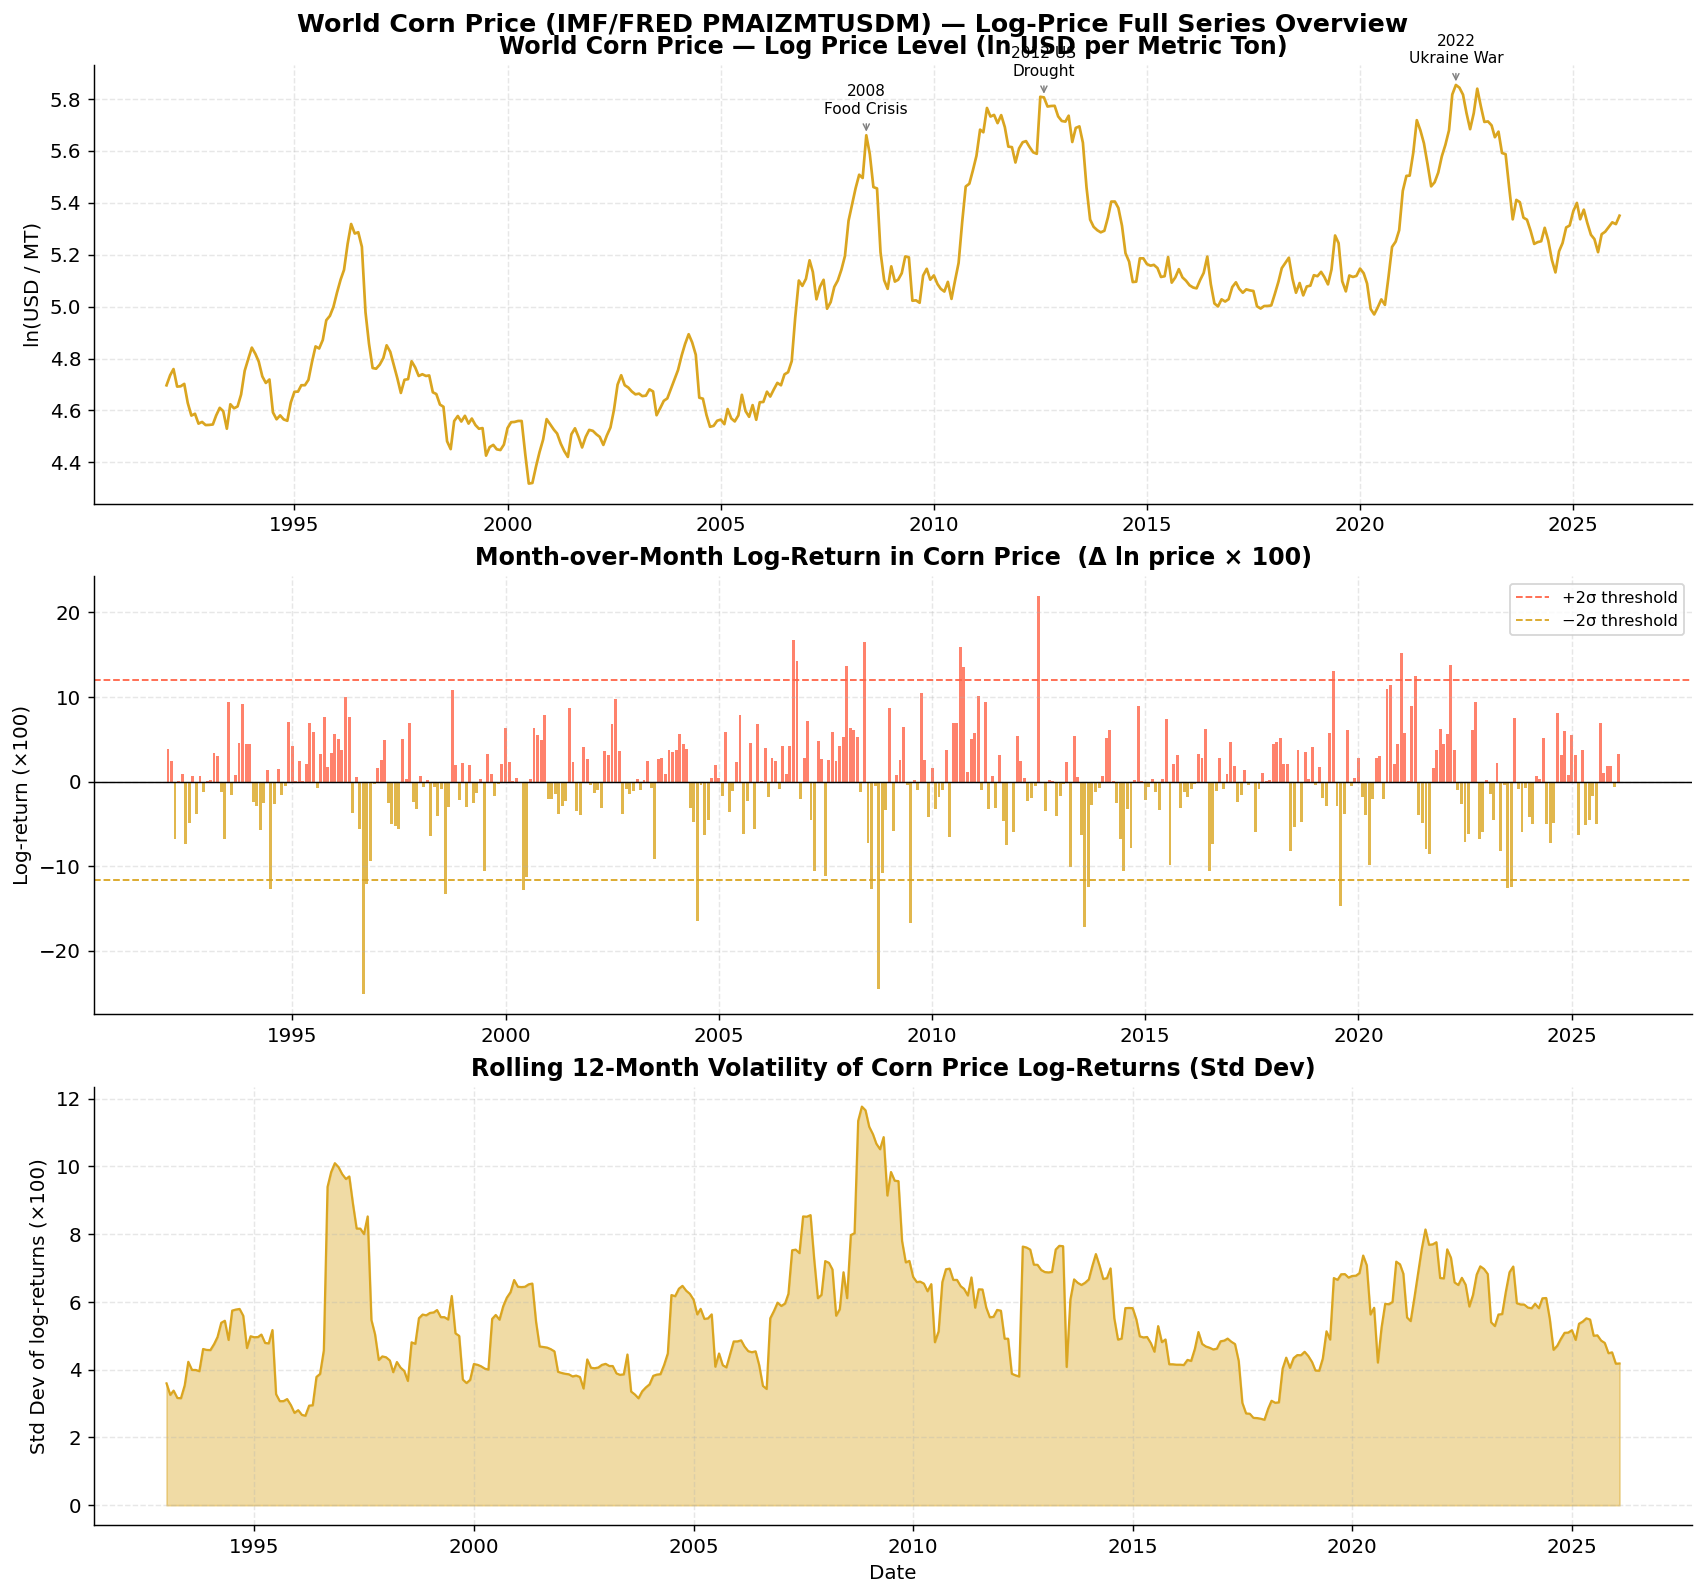

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), constrained_layout=True)

# ── Panel 1: Log price level ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(corn.index, corn.corn_log, color='goldenrod', lw=1.5)
ax.set_title('World Corn Price — Log Price Level (ln USD per Metric Ton)', fontweight='bold')
ax.set_ylabel('ln(USD / MT)')

corn_notable = {
    '2008-06-01': ('2008\nFood Crisis', 'top'),
    '2012-08-01': ('2012 US\nDrought', 'top'),
    '2022-04-01': ('2022\nUkraine War', 'top'),
}
for date_str, (label, va) in corn_notable.items():
    dt = pd.Timestamp(date_str)
    if dt in corn.index:
        val = corn.loc[dt, 'corn_log']
        ax.annotate(label, xy=(dt, val), xytext=(0, 12),
                    textcoords='offset points', ha='center', fontsize=8.5,
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# ── Panel 2: Month-over-month log-returns ─────────────────────────────────────
ax2 = axes[1]
corn_log_ret = corn.corn_log.diff() * 100
colors = ['tomato' if x > 0 else 'goldenrod' for x in corn_log_ret]
ax2.bar(corn.index, corn_log_ret, color=colors, width=25, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(corn_log_ret.mean() + 2*corn_log_ret.std(), color='tomato',
            lw=1, ls='--', label='+2σ threshold')
ax2.axhline(corn_log_ret.mean() - 2*corn_log_ret.std(), color='goldenrod',
            lw=1, ls='--', label='−2σ threshold')
ax2.set_title('Month-over-Month Log-Return in Corn Price  (Δ ln price × 100)', fontweight='bold')
ax2.set_ylabel('Log-return (×100)')
ax2.legend(fontsize=9)

# ── Panel 3: Rolling 12-month standard deviation of log-returns ───────────────
ax3 = axes[2]
corn_roll_std = corn.corn_log.diff().rolling(12).std() * 100
ax3.fill_between(corn.index, corn_roll_std, alpha=0.4, color='goldenrod')
ax3.plot(corn.index, corn_roll_std, color='goldenrod', lw=1.2)
ax3.set_title('Rolling 12-Month Volatility of Corn Price Log-Returns (Std Dev)', fontweight='bold')
ax3.set_ylabel('Std Dev of log-returns (×100)')
ax3.set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('World Corn Price (IMF/FRED PMAIZMTUSDM) — Log-Price Full Series Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

---
## 4. Side-by-Side Comparison: Do They Move Together?

Both series should broadly co-move since corn is the primary ingredient in animal feed. We compare on the overlapping date range using z-scored **log-price levels** (Panel 1) and a rolling 24-month Pearson correlation of **log-returns** (Panel 2). The correlation is computed on log-returns (first differences of log prices) rather than levels to avoid spurious correlation from shared trends.

Overall Pearson correlation (log-returns): r = 0.362


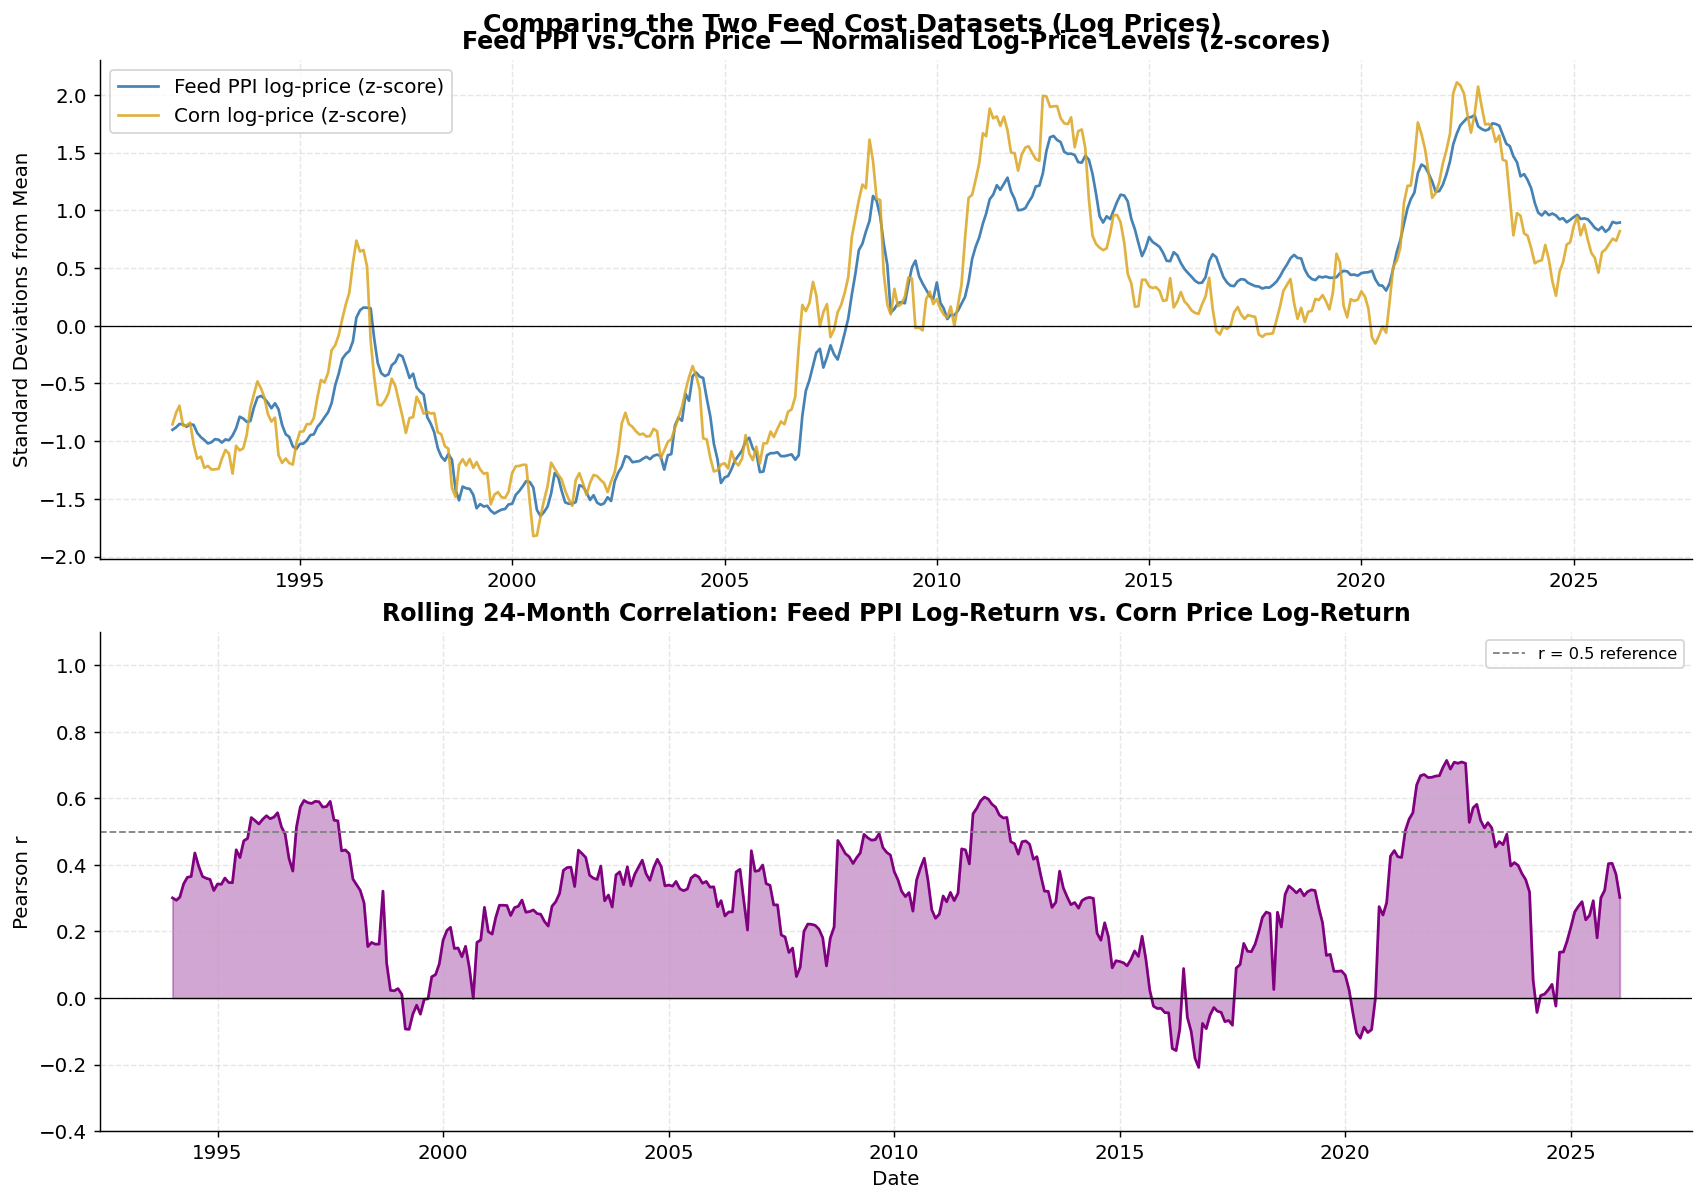

In [ ]:
# Align on overlapping date range
overlap_start = max(feed_ppi.index.min(), corn.index.min())
overlap_end   = min(feed_ppi.index.max(), corn.index.max())

ppi_log_overlap  = feed_ppi.loc[overlap_start:overlap_end, 'feed_ppi_log']
corn_log_overlap = corn.loc[overlap_start:overlap_end, 'corn_log']

# Normalize log-price levels to z-scores for visual comparison
ppi_z  = (ppi_log_overlap  - ppi_log_overlap.mean())  / ppi_log_overlap.std()
corn_z = (corn_log_overlap - corn_log_overlap.mean()) / corn_log_overlap.std()

fig, axes = plt.subplots(2, 1, figsize=(13, 9), constrained_layout=True)

# ── Panel 1: Normalized log-price levels overlaid ─────────────────────────────
ax = axes[0]
ax.plot(ppi_z.index,  ppi_z,  color='steelblue', lw=1.5, label='Feed PPI log-price (z-score)')
ax.plot(corn_z.index, corn_z, color='goldenrod', lw=1.5, alpha=0.85, label='Corn log-price (z-score)')
ax.axhline(0, color='black', lw=0.7)
ax.set_title('Feed PPI vs. Corn Price — Normalised Log-Price Levels (z-scores)', fontweight='bold')
ax.set_ylabel('Standard Deviations from Mean')
ax.legend()

# ── Panel 2: Rolling 24-month correlation of log-returns ──────────────────────
ax2 = axes[1]
combined = pd.concat([ppi_log_overlap.diff(), corn_log_overlap.diff()],
                     axis=1, keys=['feed_ppi_lr', 'corn_lr'])
roll_corr = combined['feed_ppi_lr'].rolling(24).corr(combined['corn_lr'])

ax2.fill_between(roll_corr.index, roll_corr, alpha=0.35, color='purple')
ax2.plot(roll_corr.index, roll_corr, color='purple', lw=1.5)
ax2.axhline(0, color='black', lw=0.7)
ax2.axhline(0.5, color='gray', lw=1, ls='--', label='r = 0.5 reference')
ax2.set_ylim(-0.4, 1.1)
ax2.set_title('Rolling 24-Month Correlation: Feed PPI Log-Return vs. Corn Price Log-Return',
              fontweight='bold')
ax2.set_ylabel('Pearson r')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

overall_corr = combined['feed_ppi_lr'].corr(combined['corn_lr'])
print(f'Overall Pearson correlation (log-returns): r = {overall_corr:.3f}')

plt.suptitle('Comparing the Two Feed Cost Datasets (Log Prices)',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

---
## 5. Identifying Large Feed Cost Shock Episodes

We flag months where the month-over-month **log-return** in each series exceeds ±2 standard deviations. Log-returns are more symmetric than raw percent changes, so the ±2σ threshold is better balanced between spike and drop detection — particularly for the large 2008 and 2022 commodity episodes.

=== Feed PPI shock months (|z| > 2, log-returns) ===
  1987-05  z=+2.00  log-ret≈+5.99%  ↑ spike
  1988-07  z=+4.61  log-ret≈+13.54%  ↑ spike
  1989-08  z=-2.25  log-ret≈-6.36%  ↓ drop
  1996-05  z=+2.31  log-ret≈+6.87%  ↑ spike
  1996-10  z=-3.06  log-ret≈-8.70%  ↓ drop
  1996-11  z=-2.53  log-ret≈-7.18%  ↓ drop
  1998-01  z=-2.31  log-ret≈-6.54%  ↓ drop
  1998-09  z=-3.03  log-ret≈-8.62%  ↓ drop
  2000-08  z=-2.30  log-ret≈-6.49%  ↓ drop
  2003-11  z=+2.77  log-ret≈+8.21%  ↑ spike
  2004-02  z=+2.62  log-ret≈+7.77%  ↑ spike
  2004-04  z=+2.38  log-ret≈+7.08%  ↑ spike
  2004-08  z=-2.10  log-ret≈-5.93%  ↓ drop
  2004-10  z=-2.76  log-ret≈-7.82%  ↓ drop
  2004-12  z=-2.44  log-ret≈-6.90%  ↓ drop
  2006-11  z=+3.86  log-ret≈+11.38%  ↑ spike
  2006-12  z=+2.43  log-ret≈+7.24%  ↑ spike
  2008-01  z=+2.33  log-ret≈+6.93%  ↑ spike
  2008-02  z=+2.05  log-ret≈+6.13%  ↑ spike
  2008-03  z=+2.24  log-ret≈+6.69%  ↑ spike
  2008-07  z=+2.43  log-ret≈+7.22%  ↑ spike
  2008-10  z=-2.74  log-ret≈-7

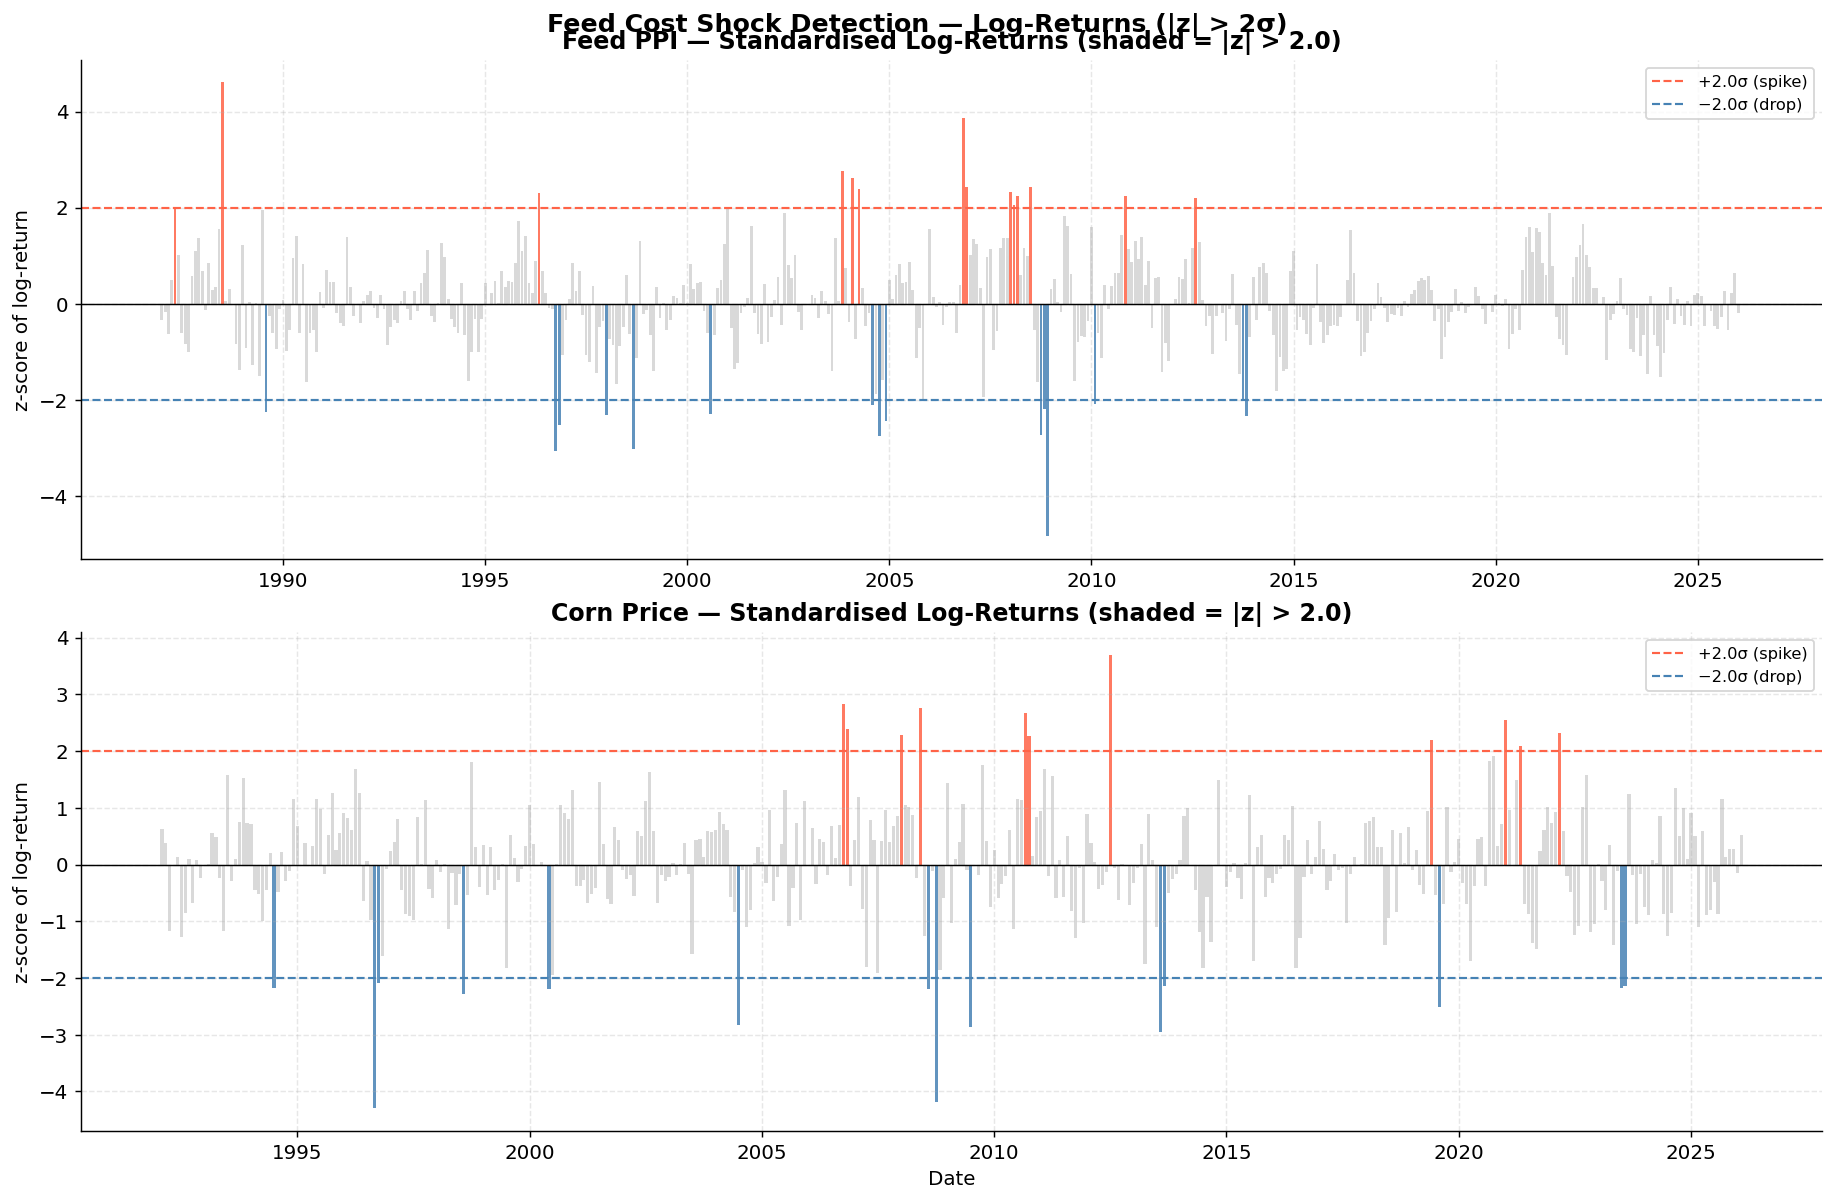

In [ ]:
def compute_log_return_zscores(log_series):
    """Return z-scored month-over-month log-returns."""
    lr = log_series.diff()
    return (lr - lr.mean()) / lr.std()

ppi_z_shocks  = compute_log_return_zscores(feed_ppi['feed_ppi_log'])
corn_z_shocks = compute_log_return_zscores(corn['corn_log'])

THRESHOLD = 2.0

fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)

for ax, z, label, color in [
    (axes[0], ppi_z_shocks,  'Feed PPI',   'steelblue'),
    (axes[1], corn_z_shocks, 'Corn Price', 'goldenrod')
]:
    ax.bar(z.index, z, color=[
        'tomato' if v >  THRESHOLD else
        'steelblue' if v < -THRESHOLD else
        'lightgray'
        for v in z
    ], width=25, alpha=0.85)
    ax.axhline( THRESHOLD, color='tomato',    lw=1.2, ls='--', label=f'+{THRESHOLD}σ (spike)')
    ax.axhline(-THRESHOLD, color='steelblue', lw=1.2, ls='--', label=f'−{THRESHOLD}σ (drop)')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label} — Standardised Log-Returns (shaded = |z| > {THRESHOLD})',
                 fontweight='bold')
    ax.set_ylabel('z-score of log-return')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].set_xlabel('Date')

# Print shock dates for both
print('=== Feed PPI shock months (|z| > 2, log-returns) ===')
for dt, val in ppi_z_shocks[ppi_z_shocks.abs() > THRESHOLD].items():
    direction = '↑ spike' if val > 0 else '↓ drop'
    # Convert z-score back to approximate log-return magnitude
    lr = feed_ppi.loc[dt, 'feed_ppi_log'] - feed_ppi['feed_ppi_log'].shift(1).loc[dt] if dt in feed_ppi.index else float('nan')
    print(f'  {dt.strftime("%Y-%m")}  z={val:+.2f}  log-ret≈{lr*100:+.2f}%  {direction}')

print('\n=== Corn Price shock months (|z| > 2, log-returns) ===')
for dt, val in corn_z_shocks[corn_z_shocks.abs() > THRESHOLD].items():
    direction = '↑ spike' if val > 0 else '↓ drop'
    lr = corn.loc[dt, 'corn_log'] - corn['corn_log'].shift(1).loc[dt] if dt in corn.index else float('nan')
    print(f'  {dt.strftime("%Y-%m")}  z={val:+.2f}  log-ret≈{lr*100:+.2f}%  {direction}')

plt.suptitle('Feed Cost Shock Detection — Log-Returns (|z| > 2σ)',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

---
## 6. Lead-Lag Analysis Preview

A central question for Aim 4: do feed cost shocks *lead* egg price shocks, and by how many months? Here we compute the cross-correlation between Feed PPI **log-returns** and Corn Price **log-returns** at various lags. When we bring in the egg price series, we'll repeat this against egg price residuals.

Log-returns are stationary (unlike log levels), making the cross-correlation well-defined and the confidence interval formula valid.

Peak cross-correlation at lag = 1 months (r = 0.637)
(Negative lag = Corn leads; positive = Feed PPI leads)


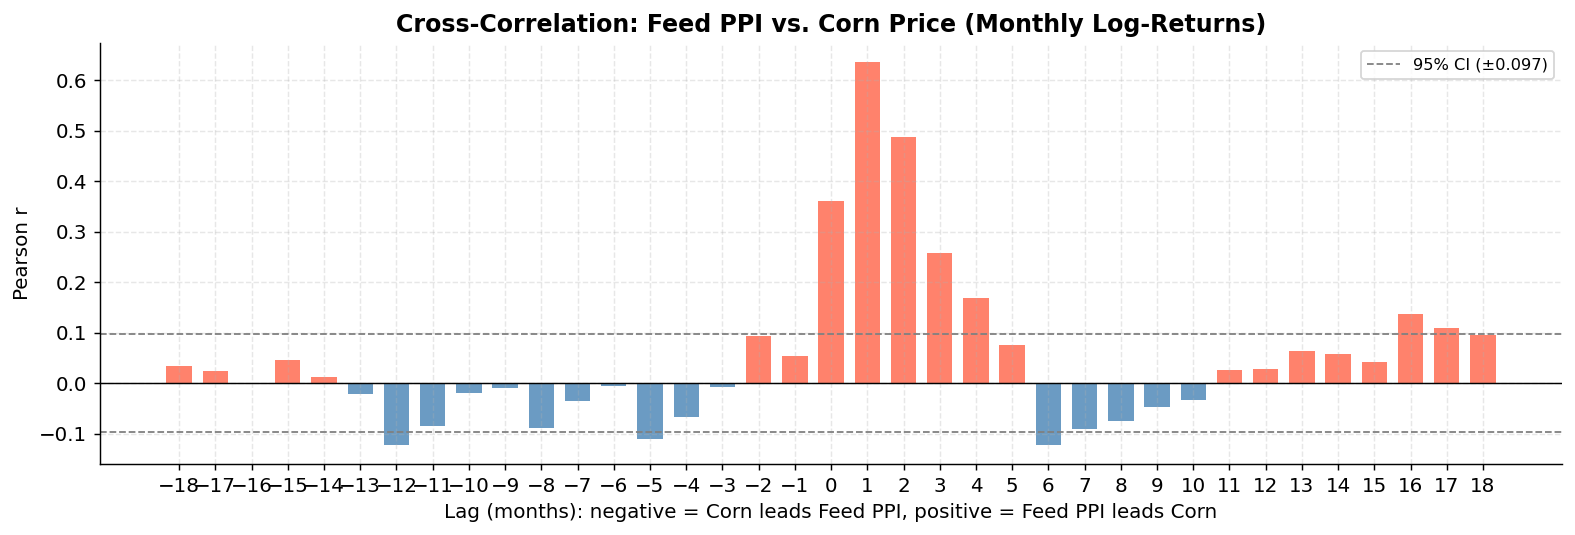

In [ ]:
# Log-returns for both series
ppi_lr  = feed_ppi['feed_ppi_log'].diff().dropna()
corn_lr = corn['corn_log'].diff().dropna()

# Align
both = pd.concat([ppi_lr, corn_lr], axis=1, keys=['feed_ppi_lr', 'corn_lr']).dropna()

max_lag = 18
lags = range(-max_lag, max_lag + 1)
ccf_vals = [both['feed_ppi_lr'].corr(both['corn_lr'].shift(lag)) for lag in lags]

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in ccf_vals]
ax.bar(list(lags), ccf_vals, color=bar_colors, alpha=0.8, width=0.7)
ax.axhline(0, color='black', lw=0.8)
n = len(both)
sig = 1.96 / np.sqrt(n)
ax.axhline( sig, color='gray', ls='--', lw=1, label=f'95% CI (±{sig:.3f})')
ax.axhline(-sig, color='gray', ls='--', lw=1)
ax.set_xlabel('Lag (months): negative = Corn leads Feed PPI, positive = Feed PPI leads Corn')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-Correlation: Feed PPI vs. Corn Price (Monthly Log-Returns)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(list(lags))

peak_lag = list(lags)[np.argmax(ccf_vals)]
print(f'Peak cross-correlation at lag = {peak_lag} months (r = {max(ccf_vals):.3f})')
print(f'(Negative lag = Corn leads; positive = Feed PPI leads)')
plt.show()

---
## 7. Summary Statistics

Descriptive table for both series on the overlapping date range, covering both log-price levels and log-returns.

In [ ]:
ppi_log_overlap  = feed_ppi.loc[overlap_start:overlap_end, 'feed_ppi_log']
corn_log_overlap = corn.loc[overlap_start:overlap_end, 'corn_log']

summary = pd.DataFrame({
    'Feed PPI (log level)':         ppi_log_overlap.describe(),
    'Corn Price (log level)':       corn_log_overlap.describe(),
    'Feed PPI (log-return ×100)':   (ppi_log_overlap.diff()*100).describe(),
    'Corn Price (log-return ×100)': (corn_log_overlap.diff()*100).describe(),
}).T.round(4)

print(f'Overlapping date range: {overlap_start.date()} to {overlap_end.date()}')
print()
print(summary.to_string())

Overlapping date range: 1992-01-01 to 2026-02-01

                              count    mean     std      min     25%     50%     75%      max
Feed PPI (log level)          410.0  5.1223  0.3339   4.5716  4.7935  5.2029  5.4177   5.7320
Corn Price (log level)        410.0  5.0301  0.3904   4.3183  4.6704  5.0696  5.2937   5.8537
Feed PPI (log-return ×100)    409.0  0.1467  2.8748 -13.8613 -1.2588  0.1514  1.6892  11.3824
Corn Price (log-return ×100)  409.0  0.1598  5.8928 -25.1764 -2.9062  0.1687  3.6754  21.9659


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

FOLDER_PATH = '/content/drive/Shareddrives/DS 440 Team 1'

feed_ppi[['feed_ppi_log']].to_csv(os.path.join(FOLDER_PATH, 'feed_ppi_log.csv'))
corn[['corn_log']].to_csv(os.path.join(FOLDER_PATH, 'corn_log.csv'))

print(f'Saved to: {FOLDER_PATH}')

Mounted at /content/drive
Saved to: /content/drive/Shareddrives/DS 440 Team 1


---
## Next Steps (Aim 4 Integration)

Once the egg price baseline model residuals are available:

1. **Load the egg price series** and compute `egg_log = np.log(egg_price)` using the same pattern as above
2. **Cross-correlate** feed PPI log-returns and corn price log-returns against lagged egg log-returns (use the same lead-lag plot structure from Section 6)
3. **Run attribution regression**: regress egg residuals on lagged feed cost log-return variables to estimate the contribution of feed costs to shock magnitude
4. **Overlay shock timelines**: plot feed cost shock flags (from Section 5) alongside egg price shock flags on the same axis to visually confirm temporal alignment
5. **Stationarity check**: before any VAR/VECM modelling, confirm log-returns are I(0) with ADF or KPSS tests — they almost certainly will be, but worth verifying